# **From Emotion Recognition to Supportive Response**

## Project overview

### **Does explicit emotion information help a model predict what type of emotional-support response should come next?**

This project trains classifiers on human-human emotional support conversations from ESConv. I use support-strategy prediction as an operational proxy: if explicit emotion information is useful for supportive decision-making, adding it should improve prediction of the strategy used on the next supporter turn.

**Skills demonstrated:** Python, scikit-learn, NLP, TF-IDF, logistic regression, multiclass classification, pretrained transformer models, experiment design, model evaluation, error analysis, data visualization

**Motivation:** AI systems are increasingly capable of identifying emotions in text. But recognizing what someone feels is not the same as understanding what they need from a conversation. A supportive response may involve asking a question, reflecting a feeling, reassuring, providing information, or offering a suggestion. I wanted to investigate how a model would behave with and without explicit emotion information.

**Goal:** Isolate the value of explicit emotion representation by comparing three controlled model variants.

| Model | Input |
|---|---|
| **A — Text Only** | Conversation history |
| **B — Text + Self-Reported Emotion** | Conversation history + ESConv emotion label |
| **C — Text + AI-Inferred Emotion** | Conversation history + 28 GoEmotions scores inferred from the latest seeker message |

**Main result:** The text-only model performs best overall. Adding either form of explicit emotion information does not improve validation performance. However, the AI-inferred emotion features substantially change the model's decisions and correct some errors, but neither emotion-aware variant improved the overall validation metrics. **Emotion recognition alone does not translate reliably into knowing how to respond.**

**Important scope:** This experiment does not test whether AI "understands humans" in a philosophical sense. It tests a narrower, measurable question about whether explicit emotion features improve support-strategy prediction in the modeling setup.

### Notebook outline

1. Load and explore the ESConv dataset
2. Construct turn-level samples and conversation-level data splits
3. Train Model A
4. Train Model B
5. Train Model C
6. Compare the three models on their decisions

## 1. Setup

This project uses ESConv (Emotional Support Conversaions), which contains conversations between a seeker who describes a difficult situation and a supporter who responds using annotated emotional-support strategies.

The dataset contains 1,300 conversations. Each conversation includes a broad self-reported `emotion_type`, a situation description, a problem type, the dialogue, and strategy annotations for supporter turns.

In [59]:
!pip -q install transformers

In [60]:
import json
import random
import requests

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

RANDOM_STATE = 42

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

In [61]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [62]:
import torch

from tqdm.auto import tqdm
from transformers import pipeline

In [63]:
ESCONV_URL = (
    "https://raw.githubusercontent.com/"
    "thu-coai/Emotional-Support-Conversation/main/ESConv.json"
)

response = requests.get(ESCONV_URL, timeout=60)
response.raise_for_status()

conversations = response.json()

print("Number of conversations:", len(conversations))
print("Type:", type(conversations))

Number of conversations: 1300
Type: <class 'list'>


In [64]:
first_conversation = conversations[0]

print(first_conversation.keys())

dict_keys(['experience_type', 'emotion_type', 'problem_type', 'situation', 'survey_score', 'dialog', 'seeker_question1', 'seeker_question2', 'supporter_question1', 'supporter_question2'])


In [65]:
print("Emotion:", first_conversation.get("emotion_type"))
print("Problem:", first_conversation.get("problem_type"))
print("Situation:", first_conversation.get("situation"))

print("\nFirst few dialogue turns:\n")

for turn in first_conversation["dialog"][:5]:
    print(turn)
    print()

Emotion: anxiety
Problem: job crisis
Situation: I hate my job but I am scared to quit and seek a new career.

First few dialogue turns:

{'speaker': 'seeker', 'annotation': {}, 'content': 'Hello\n'}

{'speaker': 'supporter', 'annotation': {'strategy': 'Question'}, 'content': 'Hello, what would you like to talk about?'}

{'speaker': 'seeker', 'annotation': {}, 'content': 'I am having a lot of anxiety about quitting my current job. It is too stressful but pays well\n'}

{'speaker': 'supporter', 'annotation': {'strategy': 'Question'}, 'content': 'What makes your job stressful for you?'}

{'speaker': 'seeker', 'annotation': {'feedback': '5'}, 'content': 'I have to deal with many people in hard financial situations and it is upsetting \n'}



This output shows part of one example conversation between a seeker and supporter. The dataset also contains the seeker's self-reported emotion and the strategy annotation for each supporter response.


In [66]:
emotion_counts = pd.Series(
    [conversation.get("emotion_type") for conversation in conversations]
).value_counts(dropna=False)

emotion_counts

,count
anxiety,354
depression,334
sadness,308
anger,111
fear,95
shame,42
disgust,40
nervousness,13
pain,1
jealousy,1


This shows how many conversations belong to each self-reported emotion category.

## 2. Support-strategy prediction task

For every annotated supporter turn, the model receives the conversation history up to that point and predicts which of eight strategies the supporter uses next:
1. Question
2. Restatement or paraphrasing
3. Reflection of feelings
4. Self-disclosure
5. Affirmation and reassurance
6. Providing suggestions
7. Information
8. Others

The target is the strategy actually chosen by the human supporter in ESConv. This gives the project a consistent supervised-learning target.

In [67]:
STRATEGIES = [
    "Question",
    "Restatement or Paraphrasing",
    "Reflection of feelings",
    "Self-disclosure",
    "Affirmation and Reassurance",
    "Providing Suggestions",
    "Information",
    "Others",
]

# For future usage
SHORT_LABELS = [
    "Question",
    "Restatement",
    "Reflection",
    "Self-disclosure",
    "Affirmation",
    "Suggestions",
    "Information",
    "Others",
]

In [68]:
def clean_text(text):
    if text is None:
        return ""

    return " ".join(str(text).split())


def normalize_strategy(strategy):
    if strategy is None:
        return None

    return clean_text(strategy).strip("[]").strip()


def format_history(history):
    lines = []

    for turn in history:

        if turn["speaker"] == "seeker":
            role = "Seeker"
        else:
            role = "Supporter"

        lines.append(f"{role}: {turn['text']}")

    return "\n".join(lines)

### 2.1 Build samples

A separate sample is created for each annotated supporter turn. The input preserves speaker labels and includes only information available before the target response.

In [69]:
def build_strategy_samples(conversations):

    rows = []

    for conversation_id, conversation in enumerate(conversations):

        history = []
        seen_seeker = False

        for turn_id, turn in enumerate(conversation.get("dialog", [])):

            speaker = str(turn.get("speaker", "")).lower().strip()
            text = clean_text(turn.get("content", ""))

            if speaker not in {"seeker", "supporter"}:
                continue

            if not text:
                continue

            if speaker == "supporter":

                annotation = turn.get("annotation") or {}

                strategy = normalize_strategy(
                    annotation.get("strategy")
                )

                # Only create a sample if:
                # - the seeker has already spoken
                # - the strategy is one of our 8 valid labels
                if (
                    seen_seeker
                    and strategy in STRATEGIES
                ):

                    rows.append({
                        "conversation_id": conversation_id,
                        "turn_id": turn_id,

                        "history_text": format_history(history),

                        "emotion_type": clean_text(
                            conversation.get("emotion_type", "")
                        ),

                        "problem_type": clean_text(
                            conversation.get("problem_type", "")
                        ),

                        "target_strategy": strategy,

                        # We keep it only for later error analysis.
                        "reference_response": text,
                    })

            history.append({
                "speaker": speaker,
                "text": text,
            })

            if speaker == "seeker":
                seen_seeker = True

    return pd.DataFrame(rows)

In [70]:
samples = build_strategy_samples(conversations)

print("Number of strategy-prediction samples:", len(samples))

samples.head()

Number of strategy-prediction samples: 17645


,conversation_id,turn_id,history_text,emotion_type,problem_type,target_strategy,reference_response
0,0,1,Seeker: Hello,anxiety,job crisis,Question,"Hello, what would you like to talk about?"
1,0,3,"Seeker: Hello\nSupporter: Hello, what would yo...",anxiety,job crisis,Question,What makes your job stressful for you?
2,0,5,"Seeker: Hello\nSupporter: Hello, what would yo...",anxiety,job crisis,Question,Do you help your clients to make it to a bette...
3,0,7,"Seeker: Hello\nSupporter: Hello, what would yo...",anxiety,job crisis,Affirmation and Reassurance,But you offer them a better future than what t...
4,0,9,"Seeker: Hello\nSupporter: Hello, what would yo...",anxiety,job crisis,Affirmation and Reassurance,I can understand that.


This produces 17,645 strategy-prediction samples.

In [71]:
example = samples.sample(
    1,
    random_state=RANDOM_STATE
).iloc[0]

print("=" * 70)
print("MODEL INPUT — CONVERSATION HISTORY")
print("=" * 70)

print(example["history_text"])

print("\n" + "=" * 70)
print("TARGET STRATEGY")
print("=" * 70)

print(example["target_strategy"])

print("\n" + "=" * 70)
print("ACTUAL HUMAN SUPPORTER RESPONSE")
print("=" * 70)

print(example["reference_response"])

print("\nEmotion:", example["emotion_type"])
print("Problem type:", example["problem_type"])

MODEL INPUT — CONVERSATION HISTORY
Seeker: So it really happened just like that
Supporter: What happened?
Seeker: My life just got flipped-turned upside down
Seeker: In West Philadelphia born and raised, on the playground is where I spent most of my days
Seeker: Chilling out maxing relaxing all cool and all shooting some b-ball outside of school
Seeker: when a couple of guys who were up to no good
Supporter: It seems like you are feeling a little bit like the Fresh Prince of Bell-Air.
Supporter: Are you having any problems that I can help you with today?
Seeker: First diagnosis was accurate so I can only trust you from here on out
Seeker: You see I was just 14 when my parents built a very strange machine
Seeker: it was designed to view a world unseen
Supporter: Sounds good. I am glad that you trust me. What did the strange machine do?
Seeker: When it didn't quite work, my folks just quit so I decided to take a look inside of it
Seeker: there was a great big flash
Seeker: everything jus

This is one example of one dialogue sample. It shows the target strategy for this conversation is restatement or paraphrasing.

In [72]:
strategy_counts = samples["target_strategy"].value_counts()

strategy_counts

,count
target_strategy,
Question,3307
Others,3134
Providing Suggestions,2948
Affirmation and Reassurance,2816
Self-disclosure,1711
Reflection of feelings,1433
Information,1213
Restatement or Paraphrasing,1083


This shows the number of samples for each target strategy in the dataset.

## 3. Evaluation desigh

Multiple prediction samples come from the same conversation. To prevent leakage, I split at the conversation level: 910 conversations for training, 195 conversations for validation, and 195 conversations for test. Each has 12,392, 2,637, and 2,616 samples respectively. All turns from the same conversation therefore remain in the same split.

In [73]:
conversation_ids = np.array(
    sorted(samples["conversation_id"].unique())
)

train_ids, temporary_ids = train_test_split(
    conversation_ids,
    test_size=0.30,
    random_state=RANDOM_STATE,
)

val_ids, test_ids = train_test_split(
    temporary_ids,
    test_size=0.50,
    random_state=RANDOM_STATE,
)

print("Train conversations:", len(train_ids))
print("Validation conversations:", len(val_ids))
print("Test conversations:", len(test_ids))

Train conversations: 910
Validation conversations: 195
Test conversations: 195


In [74]:
samples["split"] = "unassigned"

samples.loc[
    samples["conversation_id"].isin(train_ids),
    "split"
] = "train"

samples.loc[
    samples["conversation_id"].isin(val_ids),
    "split"
] = "validation"

samples.loc[
    samples["conversation_id"].isin(test_ids),
    "split"
] = "test"


train_df = samples[samples["split"] == "train"].copy()
val_df = samples[samples["split"] == "validation"].copy()
test_df = samples[samples["split"] == "test"].copy()


print("Training samples:", len(train_df))
print("Validation samples:", len(val_df))
print("Test samples:", len(test_df))

Training samples: 12392
Validation samples: 2637
Test samples: 2616


In [75]:
train_conversations = set(train_df["conversation_id"])
val_conversations = set(val_df["conversation_id"])
test_conversations = set(test_df["conversation_id"])

assert train_conversations.isdisjoint(val_conversations)
assert train_conversations.isdisjoint(test_conversations)
assert val_conversations.isdisjoint(test_conversations)

print("No conversation leakage detected.")

No conversation leakage detected.


This varifies that there is no conversation overlap across the three splits.

In [76]:
def strategy_distribution(df):
    return (
        df["target_strategy"]
        .value_counts(normalize=True)
        .reindex(STRATEGIES)
        .fillna(0)
        .round(3)
    )


distribution_table = pd.DataFrame({
    "train": strategy_distribution(train_df),
    "validation": strategy_distribution(val_df),
    "test": strategy_distribution(test_df),
})

distribution_table

,train,validation,test
target_strategy,,,
Question,0.189,0.186,0.183
Restatement or Paraphrasing,0.062,0.054,0.066
Reflection of feelings,0.081,0.083,0.080
Self-disclosure,0.097,0.088,0.104
Affirmation and Reassurance,0.158,0.165,0.159
Providing Suggestions,0.170,0.162,0.159
Information,0.071,0.073,0.055
Others,0.172,0.188,0.193


It checks that the strategy distributions remain reasonably similar across the training, validation, and test splits.



### 3.1 Dummy baseline

I establish a most-frequent-class baseline. This shows the performance obtained by ignoring the conversation and always predicting the most common support strategy.

**Evaluation matrics:**
For the future models too, I report:
- **Accuracy**: overall fraction of correct predictions
- **Macro F1**: F1 averaged equally across all eight strategies
- **Weighted F1**: F1 weighted by class frequency

where

$
F1
=
2
\frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}
$

- Precision: when the model predicts a class, how often it is correct?
- Recall: of all the real examples of that class, how many did the model find?

Macro F1 is especially important since the strategy classes are imbalanced.

In [77]:
dummy_model = DummyClassifier(
    strategy="most_frequent"
)

X_dummy_train = np.zeros((len(train_df), 1))
X_dummy_val = np.zeros((len(val_df), 1))

y_train = train_df["target_strategy"]
y_val = val_df["target_strategy"]
y_test = test_df["target_strategy"]

dummy_model.fit(
    X_dummy_train,
    train_df["target_strategy"]
)

dummy_predictions = dummy_model.predict(
    X_dummy_val
)


dummy_accuracy = accuracy_score(
    val_df["target_strategy"],
    dummy_predictions
)

dummy_macro_f1 = f1_score(
    val_df["target_strategy"],
    dummy_predictions,
    average="macro"
)

dummy_weighted_f1 = f1_score(
    y_val,
    dummy_predictions,
    average="weighted",
)

print("Dummy Baseline")
print("--------------")
print(f"Validation Accuracy:    {dummy_accuracy:.4f}")
print(f"Validation Macro F1:    {dummy_macro_f1:.4f}")
print(f"Validation Weighted F1: {dummy_weighted_f1:.4f}")

Dummy Baseline
--------------
Validation Accuracy:    0.1862
Validation Macro F1:    0.0392
Validation Weighted F1: 0.0585


The dummy classifier reaches only 18.62% validation accuracy and 0.0392 Macro F1, providing a simple reference point for the learned models.

## 4. Model A - conversation text only

Model A is trained on the turn-level samples from the training conversations. It takes the complete conversation history available before the target supporter turn as input to predict a strategy. It uses TF-IDF word unigrams and bigrams as a representation and class-balanced multiclass logistic regression as a classifier.

Emotional information can still appear implicitly through words and phrases in the conversation history.

In [78]:
model_a = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            lowercase=True,
            ngram_range=(1, 2),
            min_df=2,
            max_features=30000,
            sublinear_tf=True,
        ),
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=RANDOM_STATE,
        ),
    ),
])

In [79]:
X_train = train_df["history_text"]
X_val = val_df["history_text"]

model_a.fit(X_train, y_train)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=30000, min_df=2,
                                 ngram_range=(1, 2), sublinear_tf=True)),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=2000,
                                    random_state=42))])

### 4.1 Model A result

In [80]:
model_a_val_predictions = model_a.predict(X_val)

model_a_accuracy = accuracy_score(
    y_val,
    model_a_val_predictions,
)

model_a_macro_f1 = f1_score(
    y_val,
    model_a_val_predictions,
    average="macro",
)

model_a_weighted_f1 = f1_score(
    y_val,
    model_a_val_predictions,
    average="weighted",
)


print("Model A: Text Only")
print("------------------")
print(f"Validation Accuracy:    {model_a_accuracy:.4f}")
print(f"Validation Macro F1:    {model_a_macro_f1:.4f}")
print(f"Validation Weighted F1: {model_a_weighted_f1:.4f}")

Model A: Text Only
------------------
Validation Accuracy:    0.2871
Validation Macro F1:    0.2406
Validation Weighted F1: 0.2787


Model A reaches 28.71% validation accuracy and 0.2406 Macro F1 score, which shows an improvement from dummy baseline. This indicates that conversation text contains predictive information about the next supporter strategy.


In [81]:
model_a_report = classification_report(
    y_val,
    model_a_val_predictions,
    labels=STRATEGIES,
    output_dict=True,
    zero_division=0,
)

model_a_report_df = pd.DataFrame(
    model_a_report
).T

model_a_report_df

,precision,recall,f1-score,support
Question,0.476584,0.352342,0.405152,491.000000
Restatement or Paraphrasing,0.177165,0.316901,0.227273,142.000000
Reflection of feelings,0.182266,0.168182,0.174941,220.000000
Self-disclosure,0.128302,0.146552,0.136821,232.000000
Affirmation and Reassurance,0.247748,0.126147,0.167173,436.000000
Providing Suggestions,0.283063,0.285714,0.284382,427.000000
Information,0.082840,0.072539,0.077348,193.000000
Others,0.379452,0.558468,0.451876,496.000000
accuracy,0.287069,0.287069,0.287069,0.287069
macro avg,0.244677,0.253356,0.240621,2637.000000


This shows how well Model A predicts on each strategy class. "Question" class has the highest F1 score aside from the "Others" class while "Information" class has the lowest F1 score even though the support count is not the lowest.

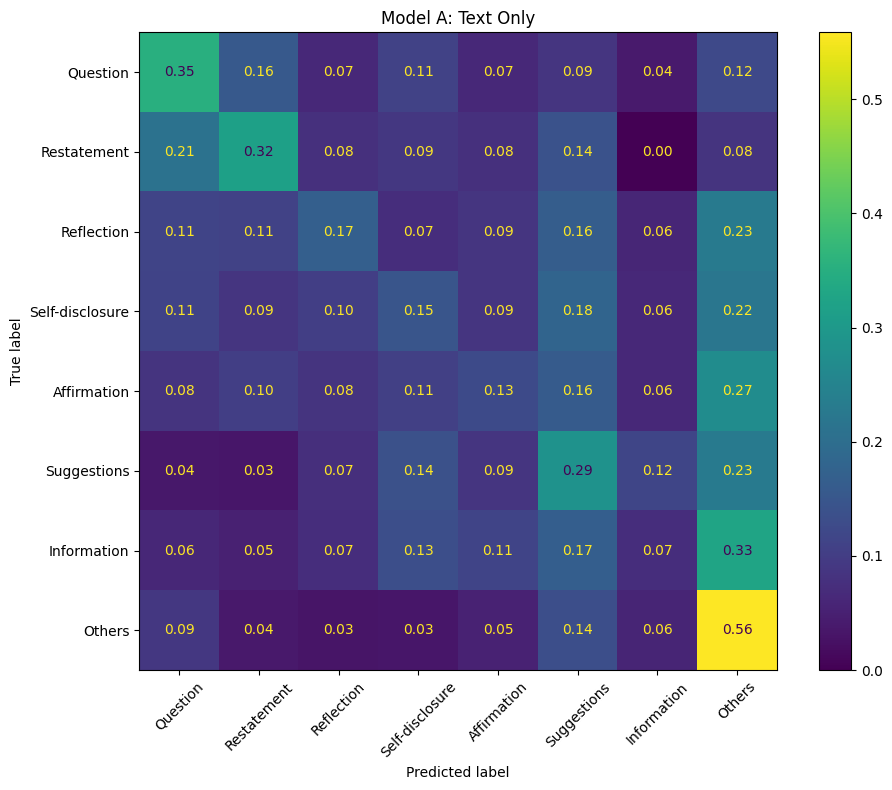

In [82]:
model_a_cm = confusion_matrix(
    y_val,
    model_a_val_predictions,
    labels=STRATEGIES,
    normalize="true",
)


fig, ax = plt.subplots(figsize=(10, 8))

display = ConfusionMatrixDisplay(
    confusion_matrix=model_a_cm,
    display_labels=SHORT_LABELS,
)

display.plot(
    ax=ax,
    xticks_rotation=45,
    values_format=".2f",
)

ax.set_title(
    "Model A: Text Only"
)

plt.tight_layout()
plt.show()

Each row is a true strategy and each column is a predicted strategy. Because the matrix is normalized by true class, diagonal values show recall for each strategy. Off-diagonal values show which classes the model confuses. Aside from "Others" class, "Question" class has a highest accuracy for Model A while Model A often mis-predicted the "Restatement" class as "Question" class, meaning these two classes are difficult to separate consistently.

In [83]:
model_a_validation_results = val_df[
    [
        "conversation_id",
        "history_text",
        "emotion_type",
        "problem_type",
        "target_strategy",
        "reference_response",
    ]
].copy()

model_a_validation_results["predicted_strategy"] = model_a_val_predictions

model_a_errors = model_a_validation_results[
    model_a_validation_results["target_strategy"]
    != model_a_validation_results["predicted_strategy"]
].copy()

print("Total validation examples:", len(model_a_validation_results))
print("Misclassified examples:", len(model_a_errors))

Total validation examples: 2637
Misclassified examples: 1880


The Model A made 2,637 validation predictions and misclassified 1,880 of them, which indicates modest performance.

In [84]:
def show_error(row):

    print("=" * 80)

    print("CONVERSATION HISTORY:\n")
    print(row["history_text"])

    print("\nTRUE STRATEGY:")
    print(row["target_strategy"])

    print("\nMODEL PREDICTION:")
    print(row["predicted_strategy"])

    print("\nHUMAN SUPPORTER RESPONSE:")
    print(row["reference_response"])

    print("\nSELF-REPORTED EMOTION:")
    print(row["emotion_type"])

    print("=" * 80)

In [85]:
sample_model_a_errors = model_a_errors.sample(
    min(5, len(model_a_errors)),
    random_state=RANDOM_STATE,
)

for _, row in sample_model_a_errors.iterrows():
    show_error(row)

CONVERSATION HISTORY:

Seeker: hello
Supporter: Hi
Seeker: how are you?
Seeker: Good day
Supporter: I am fine. How about yourself?
Seeker: i am alright, thanks
Supporter: That's good.
Seeker: yeaa
Supporter: Is there anything you need today?
Seeker: well going by my description i believe we are supposed to talk about my previous situation
Supporter: Yes we are. Would you like to tell me about it ?
Seeker: I m not sure if you saw that
Seeker: Okay easy peasy. I broke up with my boyfriend because he heated on me with my friend
Supporter: I'm sorry, no I didn't see that information. Will you explain your situation to me?
Seeker: in details?
Supporter: I see. It sound like your bothered by that.
Seeker: I had a friend i thought i could trust. i never knew both my Ex and her where sneaking behind my back
Seeker: I was
Seeker: at the time it angered me
Seeker: But im sure i moved past it
Supporter: So how did you handle that situation?
Supporter: That's good that you've moved passed it.
Seek

This shows few validation that Model A got wrong on. Some errors may reflect the difficulty of separating strategies when several responses could decently fit the same context.

## 5. Model B - text + self-reported emotion

Model B adds the ESConv `emotion_type` to the same TF-IDF text representation and logistic-regression classifier. The self-reported emotion describes the seeker's *overall* emotional situation for the conversation.

This tests whether making that emotional state explicit provides useful information beyond the conversation text itself.

In [86]:
print("Training emotion values:")
print(
    train_df["emotion_type"]
    .value_counts(dropna=False)
)

print("\nMissing or empty training emotions:")
print(
    train_df["emotion_type"]
    .isna()
    .sum()
    +
    train_df["emotion_type"]
    .eq("")
    .sum()
)

for df in [train_df, val_df, test_df]:
    df["emotion_type"] = (
        df["emotion_type"]
        .fillna("unknown")
        .replace("", "unknown")
    )

Training emotion values:
emotion_type
anxiety        3542
depression     3216
sadness        2714
anger          1098
fear            902
disgust         445
shame           360
nervousness      91
pain             12
guilt            12
Name: count, dtype: int64

Missing or empty training emotions:
0


This shows the emotion distribution across training samples. Anxiety is the most common self-reported emotion.

In [87]:
model_b_preprocessor = ColumnTransformer(
    transformers=[
        (
            "text",
            TfidfVectorizer(
                lowercase=True,
                ngram_range=(1, 2),
                min_df=2,
                max_features=30000,
                sublinear_tf=True,
            ),
            "history_text",
        ),
        (
            "emotion",
            OneHotEncoder(handle_unknown="ignore"),
            ["emotion_type"],
        ),
    ],
    remainder="drop",
)

In [88]:
model_b = Pipeline([
    (
        "features",
        model_b_preprocessor,
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=RANDOM_STATE,
        ),
    ),
])

In [89]:
MODEL_B_COLUMNS = [
    "history_text",
    "emotion_type",
]

model_b.fit(
    train_df[MODEL_B_COLUMNS],
    y_train,
)

Pipeline(steps=[('features',
                 ColumnTransformer(transformers=[('text',
                                                  TfidfVectorizer(max_features=30000,
                                                                  min_df=2,
                                                                  ngram_range=(1,
                                                                               2),
                                                                  sublinear_tf=True),
                                                  'history_text'),
                                                 ('emotion',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['emotion_type'])])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=2000,
                                    random_state=42))])

### 5.1 Model B result

In [90]:
model_b_val_predictions = model_b.predict(
    val_df[MODEL_B_COLUMNS]
)


model_b_accuracy = accuracy_score(
    y_val,
    model_b_val_predictions,
)

model_b_macro_f1 = f1_score(
    y_val,
    model_b_val_predictions,
    average="macro",
)

model_b_weighted_f1 = f1_score(
    y_val,
    model_b_val_predictions,
    average="weighted",
)


print("Model B: Text + Self-Reported Emotion")
print("-------------------------------------")
print(f"Validation Accuracy:    {model_b_accuracy:.4f}")
print(f"Validation Macro F1:    {model_b_macro_f1:.4f}")
print(f"Validation Weighted F1: {model_b_weighted_f1:.4f}")

Model B: Text + Self-Reported Emotion
-------------------------------------
Validation Accuracy:    0.2780
Validation Macro F1:    0.2338
Validation Weighted F1: 0.2726


Model B reaches 27.80% validation accuracy and 0.2338 Macro F1 score. All three matrics are slightly below Model A. **In this setup, adding the single conversation-level emotion label does not improve the validation metrics beyond the text representation.**

In [91]:
model_b_report = classification_report(
    y_val,
    model_b_val_predictions,
    labels=STRATEGIES,
    output_dict=True,
    zero_division=0,
)

model_b_report_df = pd.DataFrame(
    model_b_report
).T

model_b_report_df

,precision,recall,f1-score,support
Question,0.478754,0.344196,0.400474,491.000000
Restatement or Paraphrasing,0.146245,0.260563,0.187342,142.000000
Reflection of feelings,0.139918,0.154545,0.146868,220.000000
Self-disclosure,0.127490,0.137931,0.132505,232.000000
Affirmation and Reassurance,0.229730,0.116972,0.155015,436.000000
Providing Suggestions,0.289673,0.269321,0.279126,427.000000
Information,0.116505,0.124352,0.120301,193.000000
Others,0.380618,0.546371,0.448675,496.000000
accuracy,0.277967,0.277967,0.277967,0.277967
macro avg,0.238616,0.244282,0.233788,2637.000000


This shows how well the Model B predicts each class. It predicted the best on "Question" class aside from "Others". For some classes like "Information", Model B's F1 score is better than Model A, showing it may help with detecting those difficult-to-identify classes.

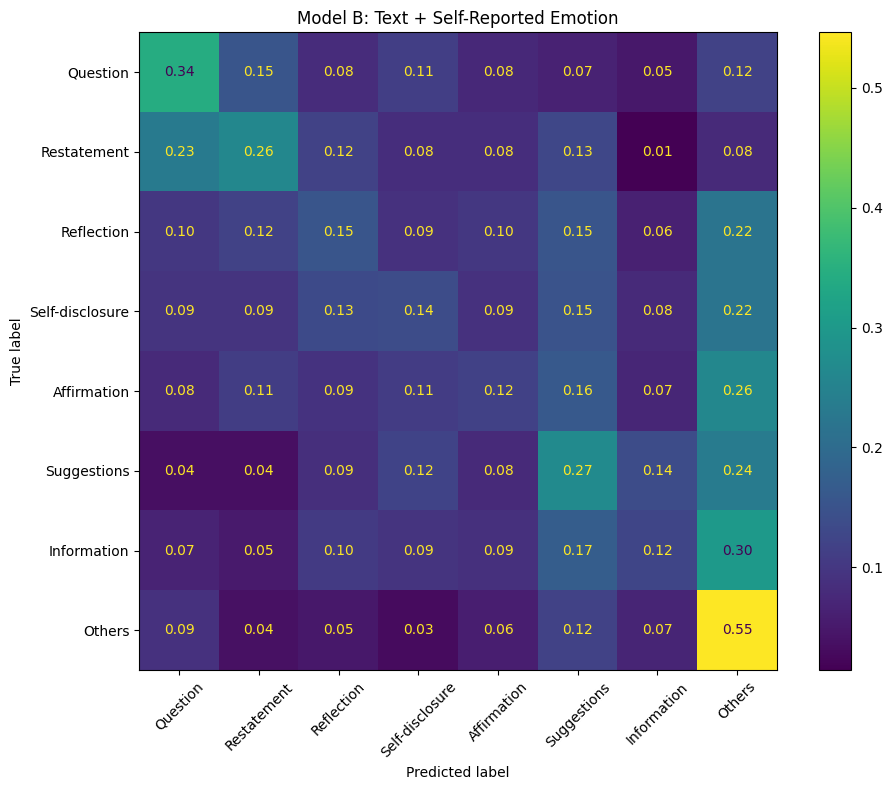

In [92]:
model_b_cm = confusion_matrix(
    y_val,
    model_b_val_predictions,
    labels=STRATEGIES,
    normalize="true",
)


fig, ax = plt.subplots(figsize=(10, 8))

display = ConfusionMatrixDisplay(
    confusion_matrix=model_b_cm,
    display_labels=SHORT_LABELS,
)

display.plot(
    ax=ax,
    xticks_rotation=45,
    values_format=".2f",
)

ax.set_title(
    "Model B: Text + Self-Reported Emotion"
)

plt.tight_layout()
plt.show()

Model B predicts most accurate on "Question" class aside from "Others" class, the same as Model A. It mispredicted "Restatement" class as "Question" class most often. But again Model B's accuracy on the "Information" class is 0.12 while Model A got 0.07, showing the explicit emotion helps predicting some classes that was difficult to identify only by texts. The overall confusion patterns remain similar between Model A and B.

The ESConv emotion label is static across the entire conversation while the support strategy can change from turn to turn. For example, a conversation label "depression" may begin with a need for questions or reflection and later shift toward reassurance, information, or suggestions. A conversation-level `emotion_type` therefore cannot fully represent what the seeker is feeling or needing at a particular turn.

## 6. Model C - text + AI-inferred emotion

Model C replaces the single self-reported emotion label with a fine-grained AI-inferred emotion representation. For each sample, I extract the most recent seeker message and use the pretrained classifier to produce scores across 28 GoEmotions labels.

Instead of keeping only the highest-scoring emotion, I retain the full probability vector. So this preserves information from multiple emotion labels instead of forcing each message into a single category.

In [93]:
def extract_latest_seeker_message(history_text):
    # Return the most recent seeker message
    lines = str(history_text).splitlines()

    for line in reversed(lines):
        if line.startswith("Seeker:"):
            return line[len("Seeker:"):].strip()

    return ""


for df in [train_df, val_df, test_df]:
    df["latest_seeker_text"] = df["history_text"].apply(
        extract_latest_seeker_message
    )


train_df[
    ["history_text", "latest_seeker_text"]
].head()

,history_text,latest_seeker_text
0,Seeker: Hello,Hello
1,"Seeker: Hello\nSupporter: Hello, what would yo...",I am having a lot of anxiety about quitting my...
2,"Seeker: Hello\nSupporter: Hello, what would yo...",I have to deal with many people in hard financ...
3,"Seeker: Hello\nSupporter: Hello, what would yo...","I do, but often they are not going to get back..."
4,"Seeker: Hello\nSupporter: Hello, what would yo...",That is true but sometimes I feel like I shoul...


For each sample, this extracts the seeker's most recent message from the available conversation history.

In [94]:
print(
    "Empty training messages:",
    train_df[
        "latest_seeker_text"
    ].eq("").sum()
)

print(
    "Empty validation messages:",
    val_df[
        "latest_seeker_text"
    ].eq("").sum()
)

Empty training messages: 0
Empty validation messages: 0


It verifies there is no empty `latest_seeker_text` for both training and validation samples.

In [95]:
EMOTION_MODEL_NAME = (
    "SamLowe/"
    "roberta-base-go_emotions"
)


DEVICE = 0 if torch.cuda.is_available() else -1

print("Using:", "GPU" if DEVICE == 0 else "CPU")

emotion_classifier = pipeline(
    task="text-classification",
    model=EMOTION_MODEL_NAME,
    top_k=None,
    device=DEVICE,
)

Using: GPU


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [96]:
example_message = (
    "My friend keeps ignoring me, "
    "and I feel like I do not matter."
)


example_emotions = emotion_classifier(
    example_message,
    truncation=True,
)[0]


example_emotions = sorted(
    example_emotions,
    key=lambda result: result["score"],
    reverse=True,
)


for result in example_emotions[:8]:

    print(
        f"{result['label']:20s}"
        f"{result['score']:.4f}"
    )

disappointment      0.5458
annoyance           0.3240
sadness             0.1623
neutral             0.0774
disapproval         0.0586
anger               0.0284
realization         0.0242
approval            0.0111


This provides a qualitative sanity check of the pretrained emotion classifier. The heighest-scoring labels are plausible for this example, although this single example is not an evaluation of emotion-recognition accuracy.

In [97]:
NUM_AI_EMOTIONS = emotion_classifier.model.config.num_labels

AI_EMOTION_LABELS = [
    emotion_classifier.model.config.id2label[i]
    for i in range(NUM_AI_EMOTIONS)
]

AI_EMOTION_COLUMNS = [
    f"ai_emotion_{label}"
    for label in AI_EMOTION_LABELS
]

print("Number of AI emotion features:", len(AI_EMOTION_COLUMNS))
print(AI_EMOTION_LABELS)

Number of AI emotion features: 28
['admiration', 'amusement', 'anger', 'annoyance', 'approval', 'caring', 'confusion', 'curiosity', 'desire', 'disappointment', 'disapproval', 'disgust', 'embarrassment', 'excitement', 'fear', 'gratitude', 'grief', 'joy', 'love', 'nervousness', 'optimism', 'pride', 'realization', 'relief', 'remorse', 'sadness', 'surprise', 'neutral']


The model provides scores for 28 labels, including admiration, amusement, and anger.

In [98]:
# Convert texts into a list into DataFrame with probabilities
def predict_emotion_probabilities(texts, batch_size):
    texts = list(texts)
    probability_rows = []

    for start in tqdm(range(0, len(texts), batch_size)):
        batch_texts = texts[start:start + batch_size]

        batch_outputs = emotion_classifier(
            batch_texts,
            truncation=True,
            max_length=512,
            batch_size=batch_size,
        )

        for output in batch_outputs:
            scores_by_label = {
                result["label"]: result["score"]
                for result in output
            }

            probability_rows.append([
                scores_by_label[label]
                for label in AI_EMOTION_LABELS
            ])

    return pd.DataFrame(
        probability_rows,
        columns=AI_EMOTION_COLUMNS,
    )

In [99]:
unique_emotion_inputs = pd.concat([
    train_df["latest_seeker_text"],
    val_df["latest_seeker_text"],
]).drop_duplicates().tolist()

print("Unique seeker messages:", len(unique_emotion_inputs))

Unique seeker messages: 11881


After removing duplicates, the training and validation splits contain 11,881 unique latest-seeker messages for emotion inference.

In [100]:
BATCH_SIZE = 64 if torch.cuda.is_available() else 16

ai_emotion_features = predict_emotion_probabilities(
    unique_emotion_inputs,
    batch_size=BATCH_SIZE,
)

  0%|          | 0/186 [00:00<?, ?it/s]

In [101]:
emotion_feature_lookup = (
    ai_emotion_features.copy()
)


emotion_feature_lookup.insert(
    0,
    "latest_seeker_text",
    unique_emotion_inputs,
)


emotion_feature_lookup.head()

,latest_seeker_text,ai_emotion_admiration,ai_emotion_amusement,ai_emotion_anger,ai_emotion_annoyance,ai_emotion_approval,ai_emotion_caring,ai_emotion_confusion,ai_emotion_curiosity,ai_emotion_desire,...,ai_emotion_love,ai_emotion_nervousness,ai_emotion_optimism,ai_emotion_pride,ai_emotion_realization,ai_emotion_relief,ai_emotion_remorse,ai_emotion_sadness,ai_emotion_surprise,ai_emotion_neutral
0,Hello,0.002758,0.001745,0.004010,0.008970,0.014486,0.001222,0.002031,0.001630,0.000869,...,0.000986,0.000382,0.001723,0.000394,0.005346,0.000340,0.000297,0.001744,0.001153,0.963458
1,I am having a lot of anxiety about quitting my...,0.021808,0.005018,0.003088,0.014070,0.055594,0.060212,0.020099,0.010005,0.008197,...,0.011036,0.533666,0.006808,0.003394,0.036411,0.022312,0.007923,0.159726,0.003337,0.029410
2,I have to deal with many people in hard financ...,0.004803,0.001471,0.015844,0.075213,0.013130,0.004380,0.003707,0.004480,0.002322,...,0.005046,0.007227,0.004145,0.000464,0.012911,0.001678,0.005424,0.518542,0.002415,0.025651
3,"I do, but often they are not going to get back...",0.002244,0.001187,0.001740,0.011205,0.013819,0.006175,0.006450,0.002975,0.005658,...,0.002826,0.006700,0.015527,0.000394,0.034024,0.002087,0.008285,0.496582,0.002299,0.466553
4,That is true but sometimes I feel like I shoul...,0.003554,0.000762,0.001595,0.008528,0.748026,0.014522,0.012247,0.003471,0.005983,...,0.005815,0.002434,0.016852,0.000823,0.093457,0.003422,0.003137,0.006459,0.000544,0.187111


This table shows the first five *latest-seeker-message* and the corresponding GoEmotions scores.

In [102]:
train_c_df = train_df.merge(
    emotion_feature_lookup,
    on="latest_seeker_text",
    how="left",
    validate="many_to_one",
)


val_c_df = val_df.merge(
    emotion_feature_lookup,
    on="latest_seeker_text",
    how="left",
    validate="many_to_one",
)

assert len(train_c_df) == len(train_df)
assert len(val_c_df) == len(val_df)

assert (
    train_c_df[
        ["conversation_id", "turn_id"]
    ]
    .reset_index(drop=True)
    .equals(
        train_df[
            ["conversation_id", "turn_id"]
        ]
        .reset_index(drop=True)
    )
)

assert (
    val_c_df[
        ["conversation_id", "turn_id"]
    ]
    .reset_index(drop=True)
    .equals(
        val_df[
            ["conversation_id", "turn_id"]
        ]
        .reset_index(drop=True)
    )
)

assert (
    train_c_df[AI_EMOTION_COLUMNS]
    .notna()
    .all()
    .all()
)

assert (
    val_c_df[AI_EMOTION_COLUMNS]
    .notna()
    .all()
    .all()
)


print(
    "AI emotion features attached successfully."
)

AI emotion features attached successfully.


### 6.1 Inspect what the AI emotion model sees

I found that the first example seeker's message has different AI emotion prediction from the self-reported emotion. It shows how the self-reported label can be too broad and static even to the message where seeker didn't show that emotion yet. But at the same time, the AI-inferred label can be too local because it sees only the latest message.

Ideally, the representation would capture the seeker's current emotional state while still using the full conversational context.

In [103]:
example_ai_emotion = (
    val_c_df.iloc[0]
)


top_emotions = (
    example_ai_emotion[
        AI_EMOTION_COLUMNS
    ]
    .sort_values(
        ascending=False
    )
    .head(5)
)


print(
    "Latest seeker message:\n"
)

print(
    example_ai_emotion[
        "latest_seeker_text"
    ]
)


print(
    "\nSelf-reported emotion:"
)

print(
    example_ai_emotion[
        "emotion_type"
    ]
)


print(
    "\nTop AI emotion signals:"
)

print(top_emotions)

Latest seeker message:

You there?

Self-reported emotion:
depression

Top AI emotion signals:
ai_emotion_neutral      0.698323
ai_emotion_curiosity     0.32292
ai_emotion_confusion     0.17214
ai_emotion_approval     0.012066
ai_emotion_surprise     0.006208
Name: 0, dtype: object


Although the conversation-level label is depression, the latest message contains little explicit emotional content, and the pretrained classifier assigns its highest score to neutral.

In [104]:
model_c_preprocessor = ColumnTransformer(
    transformers=[
        (
            "text",
            TfidfVectorizer(
                lowercase=True,
                ngram_range=(1, 2),
                min_df=2,
                max_features=30000,
                sublinear_tf=True,
            ),
            "history_text",
        ),
        (
            "ai_emotion",
            "passthrough",
            AI_EMOTION_COLUMNS,
        ),
    ],
    remainder="drop",
    sparse_threshold=1.0,
)

In [105]:
model_c = Pipeline([
    (
        "features",
        model_c_preprocessor,
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=RANDOM_STATE,
        ),
    ),
])

In [106]:
MODEL_C_COLUMNS = [
    "history_text",
    *AI_EMOTION_COLUMNS,
]

model_c.fit(
    train_c_df[MODEL_C_COLUMNS],
    y_train,
)

Pipeline(steps=[('features',
                 ColumnTransformer(sparse_threshold=1.0,
                                   transformers=[('text',
                                                  TfidfVectorizer(max_features=30000,
                                                                  min_df=2,
                                                                  ngram_range=(1,
                                                                               2),
                                                                  sublinear_tf=True),
                                                  'history_text'),
                                                 ('ai_emotion', 'passthrough',
                                                  ['ai_emotion_admiration',
                                                   'ai_emotion_amusement',
                                                   'ai_emotion_anger',
                                                   'ai_emotion_annoyance',
                                                   'ai_emotion_approval',
                                                   'ai_emotion_caring',
                                                   'ai_...
                                                   'ai_emotion_gratitude',
                                                   'ai_emotion_grief',
                                                   'ai_emotion_joy',
                                                   'ai_emotion_love',
                                                   'ai_emotion_nervousness',
                                                   'ai_emotion_optimism',
                                                   'ai_emotion_pride',
                                                   'ai_emotion_realization',
                                                   'ai_emotion_relief',
                                                   'ai_emotion_remorse',
                                                   'ai_emotion_sadness',
                                                   'ai_emotion_surprise',
                                                   'ai_emotion_neutral'])])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=2000,
                                    random_state=42))])

### 6.2 Model C result

In [107]:
model_c_val_predictions = model_c.predict(
    val_c_df[MODEL_C_COLUMNS]
)


model_c_accuracy = accuracy_score(
    y_val,
    model_c_val_predictions,
)

model_c_macro_f1 = f1_score(
    y_val,
    model_c_val_predictions,
    average="macro",
)

model_c_weighted_f1 = f1_score(
    y_val,
    model_c_val_predictions,
    average="weighted",
)


print("Model C: Text + AI-Predicted Emotion")
print("------------------------------------")
print(f"Validation Accuracy:    {model_c_accuracy:.4f}")
print(f"Validation Macro F1:    {model_c_macro_f1:.4f}")
print(f"Validation Weighted F1: {model_c_weighted_f1:.4f}")

Model C: Text + AI-Predicted Emotion
------------------------------------
Validation Accuracy:    0.2757
Validation Macro F1:    0.2383
Validation Weighted F1: 0.2783


Model C reaches 27.57% validation accuracy and 0.2383 Macro F1 score. Both Macro F1 and weighted F1 scores are better than the self-reported-emotion model, but it still does not outperform the text-only baseline model. Also, this does not show that AI understands emotion better than humans; the two models use the different measured inputs.

In [108]:
model_c_report = classification_report(
    y_val,
    model_c_val_predictions,
    labels=STRATEGIES,
    output_dict=True,
    zero_division=0,
)

model_c_report_df = pd.DataFrame(
    model_c_report
).T

model_c_report_df

,precision,recall,f1-score,support
Question,0.507463,0.346232,0.411622,491.000000
Restatement or Paraphrasing,0.157895,0.295775,0.205882,142.000000
Reflection of feelings,0.133621,0.140909,0.137168,220.000000
Self-disclosure,0.127572,0.133621,0.130526,232.000000
Affirmation and Reassurance,0.231293,0.155963,0.186301,436.000000
Providing Suggestions,0.264108,0.274005,0.268966,427.000000
Information,0.102459,0.129534,0.114416,193.000000
Others,0.418966,0.489919,0.451673,496.000000
accuracy,0.275692,0.275692,0.275692,0.275692
macro avg,0.242922,0.245745,0.238319,2637.000000


This shows how well Model C predicts each class. It has the highest F1 score on the "Question" class aside from the "others" class, which is the same as previous models. And for "Question" class and "Information" classes, Model C got higher F1 scores than Model A, which again shows the impact of explicit emotion in terms of identifying some classes. But these gains are not consistent across classes.

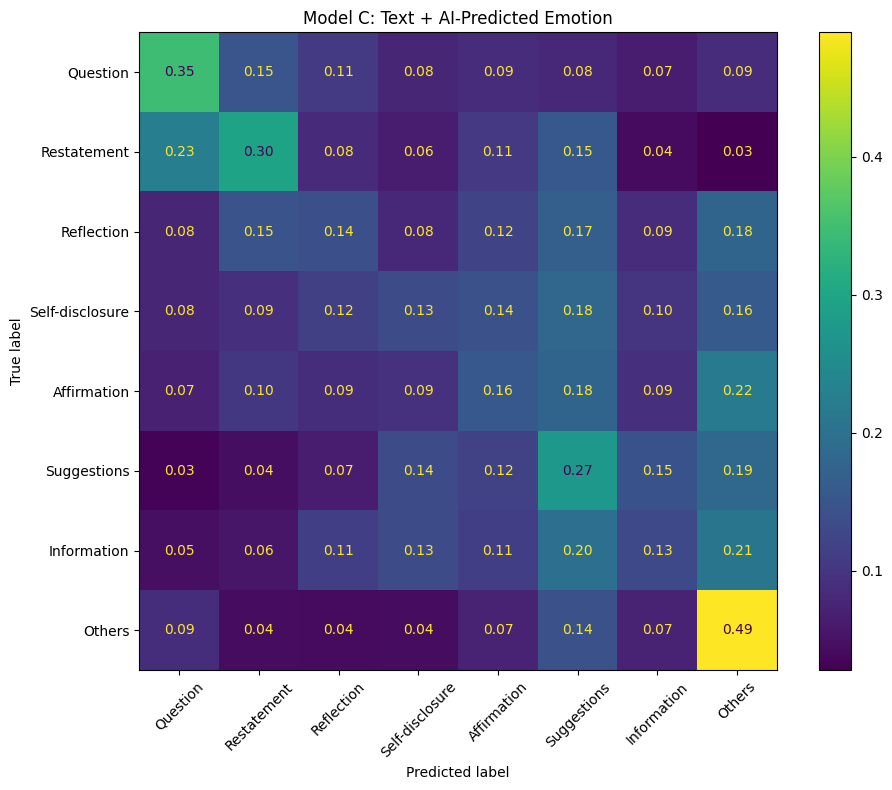

In [109]:
model_c_cm = confusion_matrix(
    y_val,
    model_c_val_predictions,
    labels=STRATEGIES,
    normalize="true",
)


fig, ax = plt.subplots(figsize=(10, 8))

display = ConfusionMatrixDisplay(
    confusion_matrix=model_c_cm,
    display_labels=SHORT_LABELS,
)

display.plot(
    ax=ax,
    xticks_rotation=45,
    values_format=".2f",
)

ax.set_title(
    "Model C: Text + AI-Predicted Emotion"
)

plt.tight_layout()
plt.show()

Model C has its highest non-"Others" recall on "Question", and it misclassified the "Restatement" class as "Question" class most often. For most of the classes, its recalls are better than Model B while closer yet not as good as Model A. It shows that **the fine-grained turn-level AI representation is more useful than the coarse self-reported label on some metrics, but neither explicit emotion representation improves overall performance over conversation text alone, *in this task and under this setup***.

## 7. Comparison

To investigate deeper, I compare predictions from the emotion-aware models directly with Model A.

For each model, I count:
- how many predictions changed,
- how many baseline errors were fixed,
- and how many previously correct baseline predictions became wrong.

In [110]:
def compare_with_model_a(other_predictions, other_model_name):
    comparison = val_df[
        [
            "conversation_id",
            "turn_id",
            "history_text",
            "emotion_type",
            "problem_type",
            "target_strategy",
            "reference_response",
        ]
    ].copy()

    comparison["model_a_prediction"] = model_a_val_predictions
    comparison["other_model_prediction"] = other_predictions

    comparison["model_a_correct"] = (
        comparison["model_a_prediction"]
        == comparison["target_strategy"]
    )

    comparison["other_model_correct"] = (
        comparison["other_model_prediction"]
        == comparison["target_strategy"]
    )

    comparison["prediction_changed"] = (
        comparison["model_a_prediction"]
        != comparison["other_model_prediction"]
    )

    fixed_errors = comparison[
        (~comparison["model_a_correct"])
        & comparison["other_model_correct"]
    ].copy()

    created_errors = comparison[
        comparison["model_a_correct"]
        & (~comparison["other_model_correct"])
    ].copy()

    both_wrong = comparison[
        (~comparison["model_a_correct"])
        & (~comparison["other_model_correct"])
    ].copy()

    print(other_model_name)
    print("-" * len(other_model_name))
    print("Predictions changed:", comparison["prediction_changed"].sum())
    print("Fixed Model A errors:", len(fixed_errors))
    print("Created new errors:", len(created_errors))
    print("Both models wrong:", len(both_wrong))

    return comparison, fixed_errors, created_errors, both_wrong

In [111]:
(
    model_b_comparison,
    model_b_fixed_errors,
    model_b_created_errors,
    model_b_both_wrong,
) = compare_with_model_a(
    model_b_val_predictions,
    "Model B vs Model A",
)

Model B vs Model A
------------------
Predictions changed: 300
Fixed Model A errors: 42
Created new errors: 66
Both models wrong: 1838


Model B fixes 42 errors made by Model A but introduces 66 new errors on examples Model A had classified correctly. Its net effect is therefore negative.

In [112]:
(
    model_c_comparison,
    model_c_fixed_errors,
    model_c_created_errors,
    model_c_both_wrong,
) = compare_with_model_a(
    model_c_val_predictions,
    "Model C vs Model A",
)

Model C vs Model A
------------------
Predictions changed: 787
Fixed Model A errors: 134
Created new errors: 164
Both models wrong: 1746


Model C changes 787 of Model A's predictions, fixes 134 Model A errors, and introduces 164 new errors. The emotion features clearly affect the classifier decisions, but the net effect on accuracy remains negative.

### 7.1 Overall metric comparison

The following data compares validation accuracy, Macro F1, and weighted F1 across all three models, showing adding explicit emotion information does not outperform conversation text alone in this setup.



In [113]:
model_comparison = pd.DataFrame({

    "Model": [
        "A: Text Only",
        "B: Text + Self-Reported Emotion",
        "C: Text + AI-Predicted Emotion",
    ],

    "Accuracy": [
        model_a_accuracy,
        model_b_accuracy,
        model_c_accuracy,
    ],

    "Macro F1": [
        model_a_macro_f1,
        model_b_macro_f1,
        model_c_macro_f1,
    ],

    "Weighted F1": [
        model_a_weighted_f1,
        model_b_weighted_f1,
        model_c_weighted_f1,
    ],
})


model_comparison.round(4)

,Model,Accuracy,Macro F1,Weighted F1
0,A: Text Only,0.2871,0.2406,0.2787
1,B: Text + Self-Reported Emotion,0.2780,0.2338,0.2726
2,C: Text + AI-Predicted Emotion,0.2757,0.2383,0.2783


In [114]:
print(
    "Model B change from A:",
    f"{model_b_macro_f1 - model_a_macro_f1:+.4f}"
)

print(
    "Model C change from A:",
    f"{model_c_macro_f1 - model_a_macro_f1:+.4f}"
)

print(
    "Model C change from B:",
    f"{model_c_macro_f1 - model_b_macro_f1:+.4f}"
)

Model B change from A: -0.0068
Model C change from A: -0.0023
Model C change from B: +0.0045


Model A has the highest validation accuracy and Macro F1. Model C improves Macro F1 and weighted F1 over Model B, although its accuracy is slightly lower.

### 7.2 Per-class F1 comparison

In [115]:
per_class_comparison = pd.DataFrame({

    "Model A: Text Only": [
        model_a_report[strategy]["f1-score"]
        for strategy in STRATEGIES
    ],

    "Model B: Self-Reported Emotion": [
        model_b_report[strategy]["f1-score"]
        for strategy in STRATEGIES
    ],

    "Model C: AI-Predicted Emotion": [
        model_c_report[strategy]["f1-score"]
        for strategy in STRATEGIES
    ],

}, index=STRATEGIES)


per_class_comparison.round(3)

,Model A: Text Only,Model B: Self-Reported Emotion,Model C: AI-Predicted Emotion
Question,0.405,0.400,0.412
Restatement or Paraphrasing,0.227,0.187,0.206
Reflection of feelings,0.175,0.147,0.137
Self-disclosure,0.137,0.133,0.131
Affirmation and Reassurance,0.167,0.155,0.186
Providing Suggestions,0.284,0.279,0.269
Information,0.077,0.120,0.114
Others,0.452,0.449,0.452


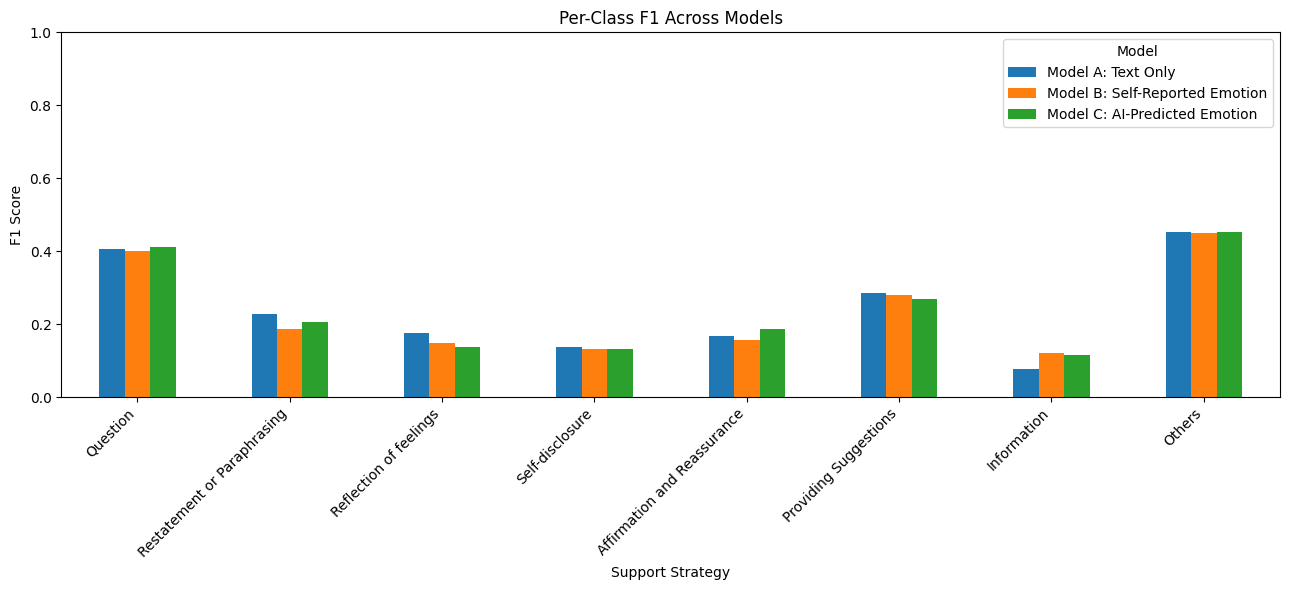

In [116]:
ax = per_class_comparison.plot(
    kind="bar",
    figsize=(13, 6),
)

ax.set_title(
    "Per-Class F1 Across Models"
)

ax.set_xlabel(
    "Support Strategy"
)

ax.set_ylabel(
    "F1 Score"
)

ax.set_ylim(
    0,
    1,
)

plt.xticks(
    rotation=45,
    ha="right",
)

plt.legend(
    title="Model"
)

plt.tight_layout()
plt.show()

For some classes like "Question", "Affirmation and Reassurance", and "Information", Model C shows the highest F1 scores. Model C improves F1 over Model B for some classes, but not for everything.

## 8. Main findings

Across the three model variants, **adding explicit emotion features did not improve overall validation performance beyond conversation text alone**.

1. Recognizing emotion and choosing a support strategy are different tasks. Emotion may be relevant, but the appropriate next strategy can also depend on intent, dialogue stage, previous responses, and broader context.

2. The text baseline already contains implicit emotional information. TF-IDF captures emotional words and phrases from the conversation history, so an additional explicit emotion representation may provide limited new information.

3. The two emotion representations have different limitations. The ESConv self-reported emotion is static across the conversation, while the GoEmotions representation is inferred only from the latest seeker message and may miss earlier context.

4. The target strategy is an imperfect proxy for what the seeker needs. ESConv provides one annotated strategy for each supporter response, even though multiple strategies may sometimes be reasonable in the same context.

Model C affected the classifier's decisions and improved some class-level results, but those gains were not consistent enough to improve the overall metrics. In this setup, explicitly identifying emotion was not sufficient to make support-strategy prediction more reliable.

## 9. Limitations

1. ESConv provides only one human-selected response strategy, so not all other responses should be incorrect.

2. Self-reported emotion is conversation level, so it does not capture emotional change across individual turns.

3. AI emotion is latest message level, so it may miss earlier turns' contexts.

4. The pretrained GoEmotions model was developed for a different emotion-labeling task and may not capture the signals most relevant to ESConv support strategies.

5. The downstream model is linear. Logistic regression cannot naturally model complex interactions among emotion, intent, dialogue stage, and context.

6. The project does not directly evaluate generated response quality, user satisfaction, empathy, or long-term conversational outcomes.

7. Results are based on one conversation split, so very small differences between models should not be treated as affirmed rankings.

## 10. Future work

Potential follow-up work would be:
- infer emotion from full conversational context, not only latest message
- explicitly represent user intent and dialogue stage alongside emotion
- use a nonlinear or contextual language model that can learn interactions among those signals
- evaluate multiple acceptable support strategies instead of assuming one unique correct label
- move from strategy prediction toward evaluation of the actual generated response, including appropriateness, empathy, and user preference.

These changes would test a more realistic version of the original question: **not simply whether AI can label emotion, but whether it can use emotional and conversational context to make better supportive decisions**.

## 11. Conclusion

This project explored whether explicit emotion information improves emotional-support strategy prediction using the ESConv human-human conversation dataset. A TF-IDF + logistic regression text baseline was compared with models using self-reported emotion and AI-inferred emotion features.

The results showed that adding explicit emotion information did not improve the overall metrics. AI-inferred emotion provided useful signals in some individual cases, but much of the relevant emotional information may already be present in the conversation text, and support-strategy choice depends on more than emotion alone.

Future work could include testing stronger contextual language models, improving how emotion features are weighted or represented, using longer conversation context for emotion inference, and exploring whether multiple appropriate support strategies should be considered instead of treating each example as having only one correct response type.
